# import modules

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from functions import *
plt.rcParams["font.size"] = 14
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["STIXGeneral"],
    "mathtext.fontset": "stix",
})

# averaged constant fitting

ValueError: `ydata` must not be empty!

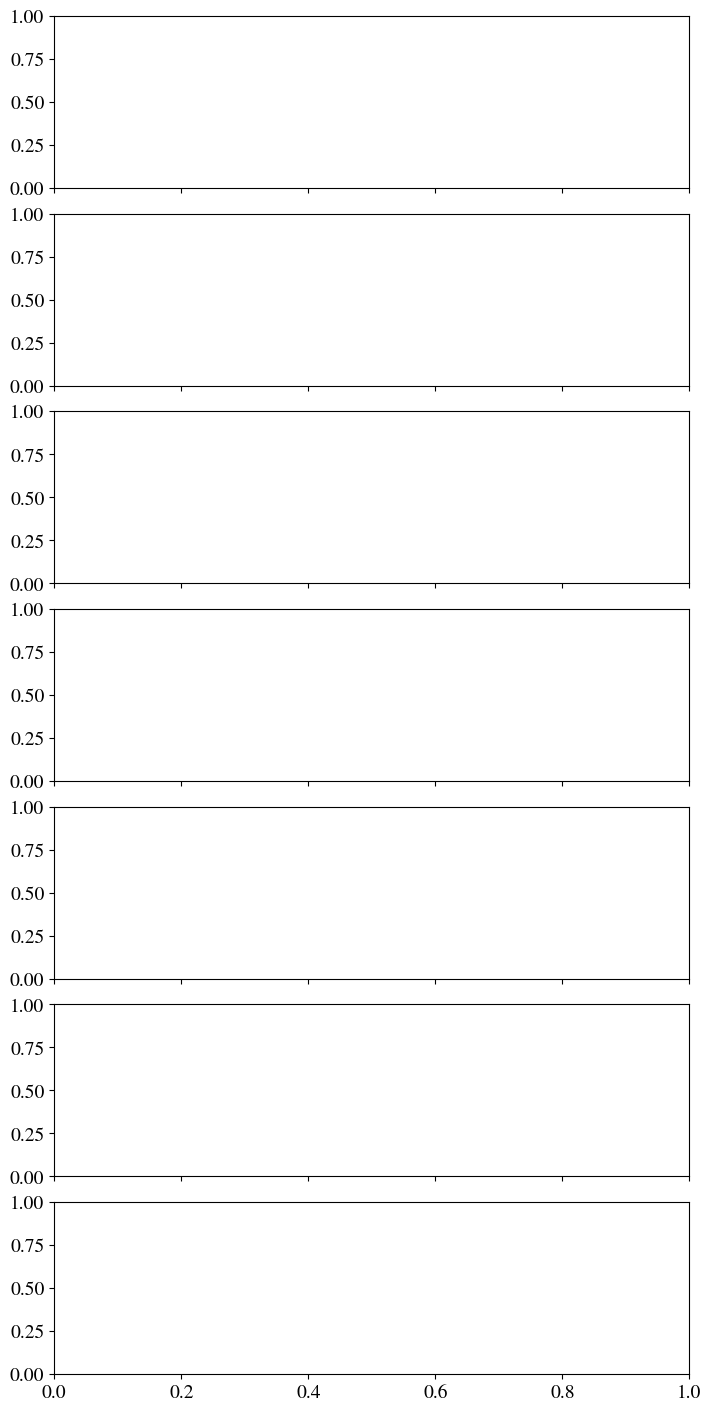

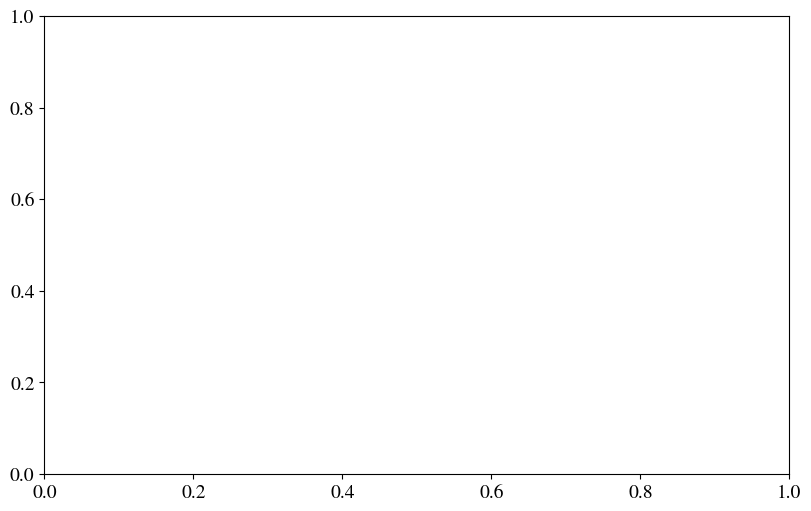

In [2]:
ThreshR = 200 # minimum radius boundary 
filteringXmax = True # condition of underground Xmax, True if filtered
energy_all = False
NmuNorm = False
lgE_GeV_bin = 16.0
RegressionFixedEnergyBin(ThreshR, filteringXmax, energy_all, lgE_GeV_bin, NmuNorm)

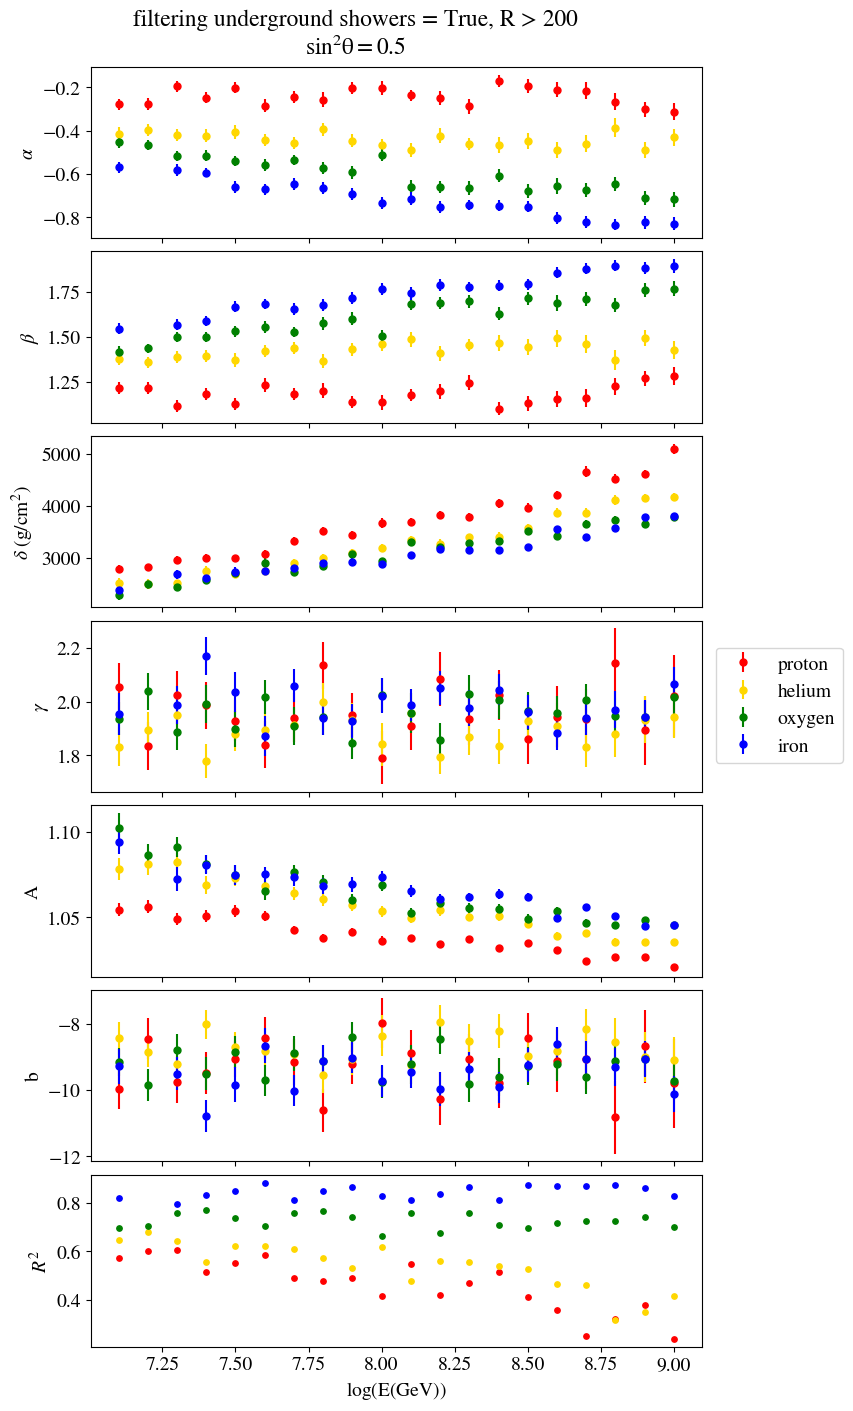

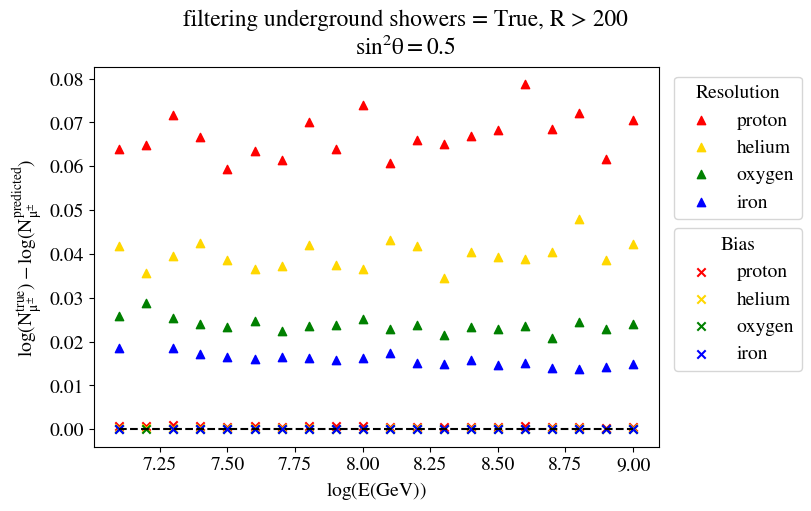

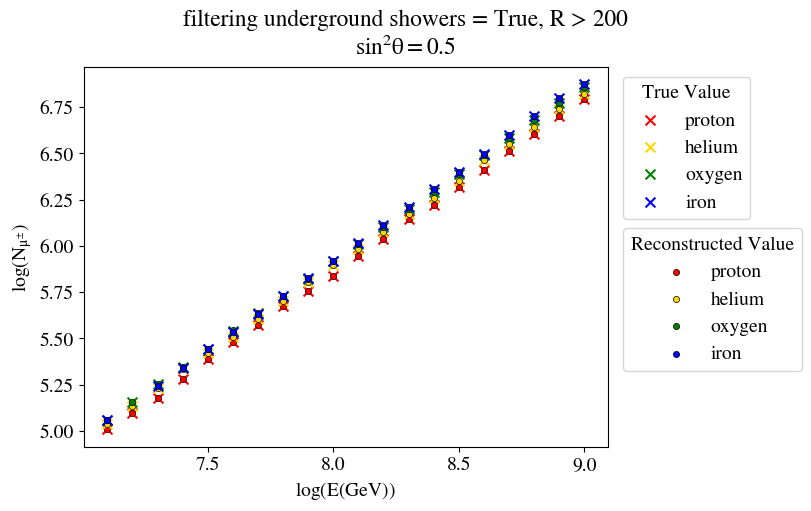

In [ ]:
ThreshR = 200
filteringXmax = True 
zenith_all = False
NmuNorm = False
sin2_bin = 0.5
RegressionFixedZenithBin(ThreshR, filteringXmax, zenith_all, sin2_bin, NmuNorm)


In [ ]:
ThreshR = 200
filteringXmax = True 
NmuNorm = False
df_params, df_Nmu = GetConstFromRegression(ThreshR, filteringXmax, NmuNorm)

# input lgE and sin2 
primEnergy = 1e7		 # primary energy in GeV should vary between 1e7 and 1e9 GeV
sin2 = 0.0 			# sin2 should vary between 0.0 and 0.8
Edep = 6			# Edep in GeV should vary between 3 and 16000 GeV 
Erad = 8e-6 				# Erad in GeV should vary between 1.5e-6 and 6 GeV 
Xmax = 622				# Xmax in g/cm^2 should vary between 450 and 1200 g/cm^2 
plotting = True 
printing = False
const_interp(df_params, primEnergy, sin2, Edep, Erad,Xmax, plotting, printing)

sin2 = 0.5

energy_bins = np.linspace(7.0, 9.0, 21)
sin2theta = df_Nmu['sin2theta']
energy = df_Nmu['energy']
particle = df_Nmu['particle']

fig, ax = plt.subplots(figsize=(8,5), constrained_layout=True)
fig2, ax2 = plt.subplots(figsize=(8,5), constrained_layout=True)

handle_bias = []
handle_res = []
handle_true = []
handle_recon = []
# colors = ['red','gold', 'green', 'blue']
# particle_bins = ['proton', 'helium', 'oxygen', 'iron']
particle_bins = ['iron', 'oxygen', 'helium', 'proton']
colors = ['blue', 'green', 'gold', 'red']
titlelabel =  f'removing underground Xmax = {filteringXmax}, R > {ThreshR} m'
zenith_label = rf'$\mathrm{{sin^2 \theta = {sin2}}}$'

for p_idx, p in enumerate(particle_bins):

	Nmu_true_all = []
	Nmu_pred_all = []
	bias_all = []
	reso_all = []
	energy_all = []

	for e_idx, e in enumerate(energy_bins):

		mask = np.isclose(sin2theta, sin2) & (energy == e) & (particle == p)
		df_mask = df_Nmu[mask]

		Nmu_true = df_mask['Nmu_true'].values
		Nmu_pred = df_mask['Nmu_pred'].values
		bias = df_mask['bias'].values
		reso = df_mask['reso'].values
		
		if not df_mask.empty:
			Nmu_true_all.append(Nmu_true)
			Nmu_pred_all.append(Nmu_pred)
			bias_all.append(bias)
			reso_all.append(reso)
			energy_all.append(e)

	bias = ax.scatter(energy_all, bias_all, color = colors[p_idx], marker = 'x', label = p )
	res = ax.scatter(energy_all, reso_all, color = colors[p_idx], marker = '^', label = p)
	
	true = ax2.scatter(energy_all, Nmu_true_all, color = colors[p_idx], marker = 'x', label = p, s = 50, zorder = 2)
	recon = ax2.scatter(energy_all, Nmu_pred_all, color = colors[p_idx], marker = 'o', label = p, s = 20, zorder = 3,
					edgecolors = 'black', linewidths=0.5, alpha = 0.7)

	handle_res.append(res)
	handle_bias.append(bias)
	handle_true.append(true)
	handle_recon.append(recon)

fig.suptitle(titlelabel + '\n' + zenith_label)
leg1 = ax.legend(bbox_to_anchor=(1.01, 1), handles= handle_res, loc='upper left', title="Resolution")
ax.add_artist(leg1) 
ax.legend(bbox_to_anchor=(1.01, 0.6), handles=handle_bias, loc='upper left', title="Bias")
ax.set_xlabel(rf'$\mathrm{{log(E (GeV))}}$')
ax.set_ylabel(rf'$\mathrm{{log(N_{{\mu^{{\pm}}}}^{{true}}) - log(N_{{\mu^{{\pm}}}}^{{reconstructed}})}}$')
ax.set_title(f'')
ax.set_ylim(-0.3,0.3)
ax.hlines(y= 0, xmin = min(energy_all), xmax= max(energy_all), colors = 'k', linestyles =  '--')

fig2.suptitle(titlelabel + '\n' + zenith_label)
leg2 = ax2.legend(bbox_to_anchor=(1.01, 1), handles= handle_true, loc='upper left', title="True Value")
ax2.add_artist(leg2) 
ax2.legend(bbox_to_anchor=(1.01, 0.6), handles=handle_recon, loc='upper left', title="Reconstructed Value")
ax2.set_xlabel(rf'$\mathrm{{log(E (GeV))}}$')
ax2.set_ylabel(rf'$\mathrm{{log(N_{{\mu^{{\pm}}}})}}$')

ValueError: Found array with 0 sample(s) (shape=(0,)) while a minimum of 1 is required.

# Fitting across primaries

/home/wkammeem/.local/lib/python3.9/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/wkammeem/.local/lib/python3.9/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


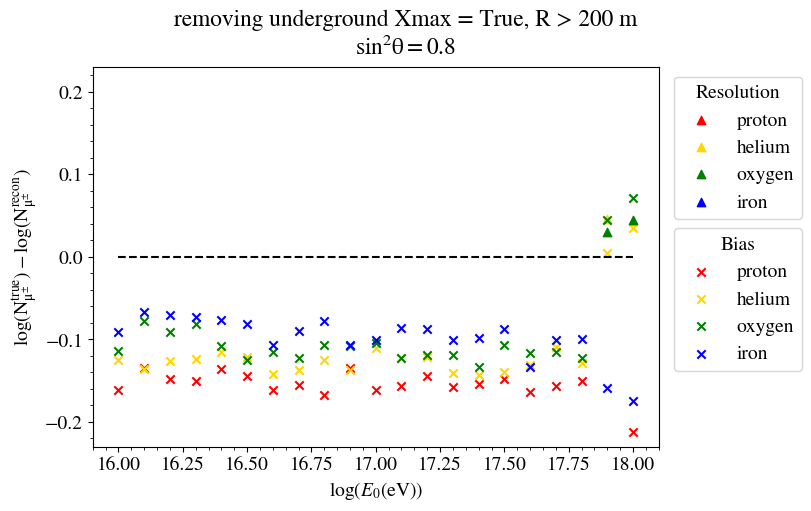

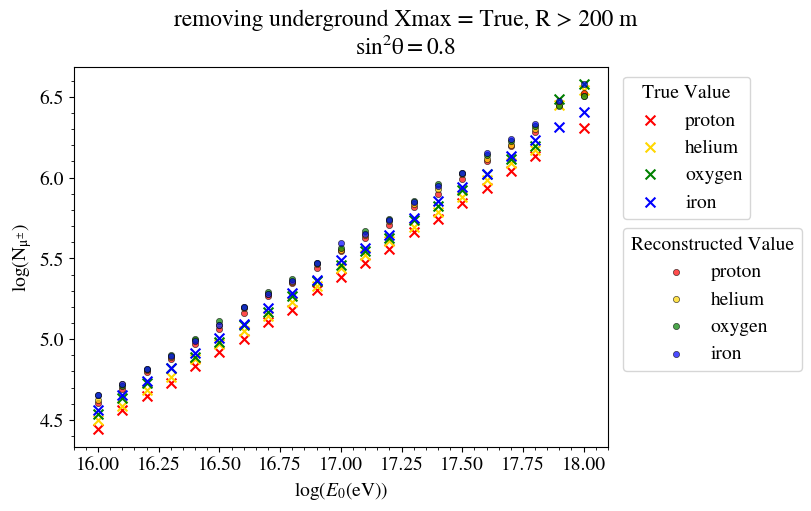

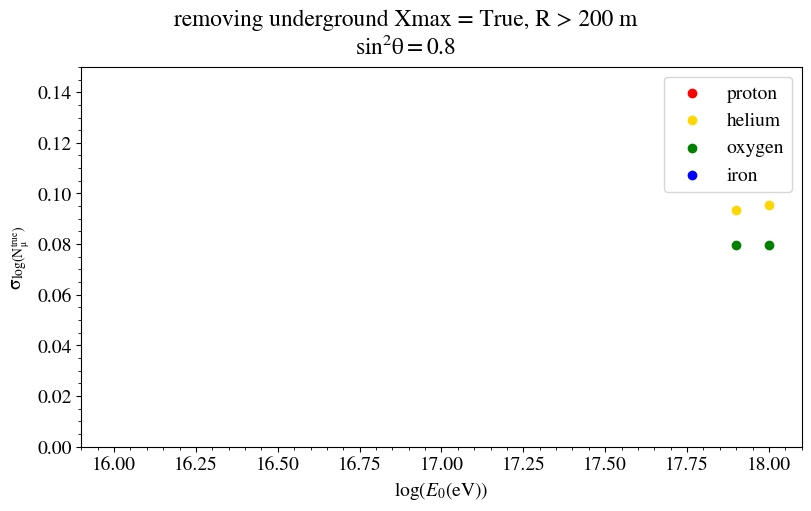

In [ ]:

minR = 200 # minimum radius in m
filteringXmax = True 
NmuNorm = False
df_params, df_Nmu = GetConstFromRegression2(minR, filteringXmax, NmuNorm)

# input lgE and sin2 
primEnergy = 1e7		# primary energy in GeV should vary between 1e7 and 1e9 GeV
sin2 = 0.5			# sin2 should vary between 0.0 and 0.8
Edep = 6				# Edep in GeV should vary between 3 and 16000 GeV 
Erad = 8e-6 			# Erad in GeV should vary between 1.5e-6 and 6 GeV 
Xmax = 622				# Xmax in g/cm^2 should vary between 450 and 1200 g/cm^2 
plotting = False 
printing = False
#const_interp(df_params, primEnergy, sin2, Edep, Erad,Xmax, plotting, printing)

plt_recon_res(df_Nmu, filteringXmax, minR, sin2)